Progetto sub-modulo 5

0_Importazione librerie necessarie

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

1_Data Exploration & Preprocessing

In [11]:
# caricamento dataset e analisi esplorativa iniziale

data = load_linnerud(as_frame=True)

print("Caratteristiche del dataset:")
display(data)

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=data.target_names)

Caratteristiche del dataset:


{'data':     Chins  Situps  Jumps
 0     5.0   162.0   60.0
 1     2.0   110.0   60.0
 2    12.0   101.0  101.0
 3    12.0   105.0   37.0
 4    13.0   155.0   58.0
 5     4.0   101.0   42.0
 6     8.0   101.0   38.0
 7     6.0   125.0   40.0
 8    15.0   200.0   40.0
 9    17.0   251.0  250.0
 10   17.0   120.0   38.0
 11   13.0   210.0  115.0
 12   14.0   215.0  105.0
 13    1.0    50.0   50.0
 14    6.0    70.0   31.0
 15   12.0   210.0  120.0
 16    4.0    60.0   25.0
 17   11.0   230.0   80.0
 18   15.0   225.0   73.0
 19    2.0   110.0   43.0,
 'feature_names': ['Chins', 'Situps', 'Jumps'],
 'target':     Weight  Waist  Pulse
 0    191.0   36.0   50.0
 1    189.0   37.0   52.0
 2    193.0   38.0   58.0
 3    162.0   35.0   62.0
 4    189.0   35.0   46.0
 5    182.0   36.0   56.0
 6    211.0   38.0   56.0
 7    167.0   34.0   60.0
 8    176.0   31.0   74.0
 9    154.0   33.0   56.0
 10   169.0   34.0   50.0
 11   166.0   33.0   52.0
 12   154.0   34.0   64.0
 13   247.0   46.0   50

In [ ]:
# standardizzazione delle feature e dei target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y)


2_Target Engineer

In [ ]:
# applicazione PCA per selezione automatica target

pca = PCA(n_components=1, random_state=42)
y_pca = pca.fit_transform(y_scaled)
y_pca = y_pca.ravel()
print(y_pca.shape)


(20,)


In [44]:
# selezione manuale del componente "Waist"
y_waist = y["Waist"]

In [63]:
# addestramento delle regressioni con PCA e manuali

mse_pca = []
r2_pca = []
mse_man =[]
r2_man =[]


models = [
    ("Regressione Lineare", LinearRegression()),
    ("Regressione Ridge", Ridge(alpha=0.1)),
    ("Regressione Lasso", Lasso(alpha=0.1))
]

for name, model in models:
    model.fit(X_scaled, y_pca)
    y_pred_pca = model.predict(X_scaled)
    mse_pca.append(mean_squared_error(y_pca, y_pred_pca))
    r2_pca.append(r2_score(y_pca, y_pred_pca))

for name, model in models:
    model.fit(X_scaled, y_waist)
    y_pred_man = model.predict(X_scaled)
    mse_man.append(mean_squared_error(y_waist, y_pred_man))
    r2_man.append(r2_score(y_waist, y_pred_man))


In [64]:
# valutazione modello

print(f"I risultati del modello con PCA sono:\\\
      \n\tMSE Lineare:\t{mse_pca[0]:.2f}\tR2 Lineare\t{r2_pca[0]:.2f}\\\
      \n\tMSE Ridge:\t{mse_pca[1]:.2f}\tR2 Ridge\t{r2_pca[1]:.2f}\\\
      \n\tMSE Lasso:\t{mse_pca[2]:.2f}\tR2 Lasso\t{r2_pca[2]:.2f}")

print(f"I risultati del modello con selezione manuale sono:\\\
      \n\tMSE Lineare:\t{mse_man[0]:.2f}\tR2 Lineare\t{r2_man[0]:.2f}\\\
      \n\tMSE Ridge:\t{mse_man[1]:.2f}\tR2 Ridge\t{r2_man[1]:.2f}\\\
      \n\tMSE Lasso:\t{mse_man[2]:.2f}\tR2 Lasso\t{r2_man[2]:.2f}")

I risultati del modello con PCA sono:\      
	MSE Lineare:	1.27	R2 Lineare	0.40\      
	MSE Ridge:	1.27	R2 Ridge	0.40\      
	MSE Lasso:	1.33	R2 Lasso	0.37
I risultati del modello con selezione manuale sono:\      
	MSE Lineare:	4.40	R2 Lineare	0.55\      
	MSE Ridge:	4.40	R2 Ridge	0.55\      
	MSE Lasso:	4.47	R2 Lasso	0.54


In [66]:
# scaling delle feature per rappresentazione 2d

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pc1 = X_pca[:, 0].reshape(-1, 1)

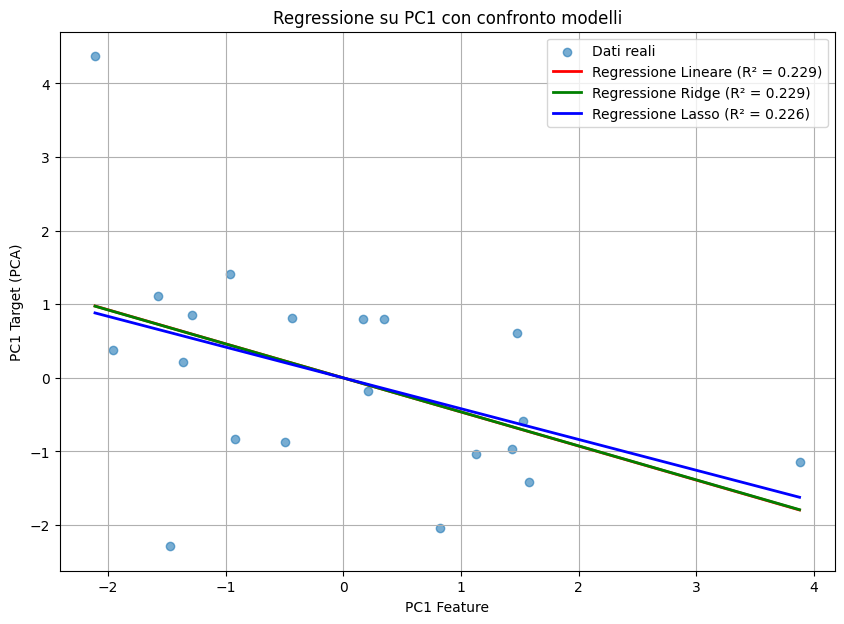

In [ ]:
# rappresentazione grafica 

plt.figure(figsize=(10, 7))
plt.scatter(pc1, y_pca, alpha=0.6, label="Dati reali")

# ordinamento dei dati
idx = np.argsort(pc1.ravel())
X_sorted = pc1.ravel()[idx]

# creazione palette colori
colors = ["red", "green", "blue"]

for (name, model), color in zip(models, colors):
    
    model.fit(pc1, y_pca)
    y_pred = model.predict(pc1)
    y_pred_sorted = y_pred[idx]
    r2 = r2_score(y_pca, y_pred)

    plt.plot(
        X_sorted,
        y_pred_sorted,
        color=color,
        linewidth=2,
        label=f"{name} (R² = {r2:.3f})"
    )

plt.xlabel("PC1 Feature")
plt.ylabel("PC1 Target (PCA)")
plt.title("Regressione su PC1 con confronto modelli")
plt.legend()
plt.grid(True)

plt.show()